https://datos.gob.es/sites/default/files/doc/file/analisis_exploratorio_de_datos_2021.pdf
https://www.ibm.com/mx-es/think/topics/exploratory-data-analysis
https://docs.aws.amazon.com/es_es/sagemaker/latest/dg/canvas-analyses.html

## **1. DATA DESCRIPTION**

## **1.1 Prices**

1. **Temporal Scope** 

    This dataset contains historical electricity prices from 01/01/2020 to 30/09/2025.

    Data after 1 October 2025 is excluded due to the transition from hourly to 15-minute resolution, ensuring temporal consistency in the analysis.


2. **Geographical Coverage**

    The dataset covers 20 bidding zones, which can be grouped into three larger regions:
    -  <u>Baltic countries </u> 

        Lithuania, Latvia and Estonia

    -  <u>Nordic countries </u> 
        
        Denmark, Finland, Norway and Sweden

    -  <u>Central Western Europe </u> 
        
        Germany, France, the Netherlands, Belgium and Austria

    Denmark, Norway and Sweden are divided into several bidding zones.

    Other bidding zones are only present during a limited period of time and they are excluded from the analysis to ensure consistency in the geographical coverage.

    - Finland-Russia Exchange (01/01/2020 - 03/06/2020)
    - Great Britain (01/01/2020 - 31/12/2020)
    - Bulgaria (02/12/2020 - present)
    - Romania (20/11/2024 - present)

3. **Temporal Field**

    Delivery day and Delivery period (CET).


4. **Granularity**

    Hourly data.

5. **Units**

    EUR/MWh

6. **Structure**

    The dataset is stored in a wide format, where each row represents a delivery period and each bidding zone is represented as a separate column.

7. **Role in the analysis**

    This dataset represents the main target variable of the study, as it contains the electricity prices to be analyzed and modeled across time and bidding zones.


## **1.2 Volumes**

1. **Temporal Scope** 

    This dataset contains historical electricity market volumes from 01/01/2020 to 30/09/2025.

    Data after 1 October 2025 is excluded due to the transition from hourly to 15-minute resolution, ensuring temporal consistency in the analysis.


2. **Geographical Coverage**

    The dataset covers 20 bidding zones, which can be grouped into three larger regions:
    -  <u>Baltic countries </u> 

        Lithuania, Latvia and Estonia

    -  <u>Nordic countries </u> 
        
        Denmark, Finland, Norway and Sweden

    -  <u>Central Western Europe </u> 
        
        Germany, France, the Netherlands, Belgium and Austria

    Denmark, Norway and Sweden are divided into several bidding zones.

    Other bidding zones are only present during a limited period of time and they are excluded from the analysis to ensure consistency in the geographical coverage.


3. **Temporal Field**

    Delivery day and Delivery period (CET).


4. **Granularity**

    Hourly data.

5. **Units**

    MWh to ensure consistency with the price dataset, which is expressed in EUR/MWh.

6. **Structure**

    The dataset is stored in a wide format. For each bidding zone, two consecutive columns are provided, corresponding to Buy and Sell volumes.

7. **Role in the analysis**

    This dataset represents market activity in each bidding zone, reflecting supply (sell volumes) and demand (buy volumes), and may help explain electricity price dynamics.

## **1.3 Flows**

1. **Temporal Scope** 

    This dataset contains historical directional energy flows from 01/01/2020 to 30/09/2025.

    Data after 1 October 2025 is excluded due to the transition from hourly to 15-minute resolution, ensuring temporal consistency in the analysis.


2. **Geographical Coverage**

    The dataset covers directional interconnections between bidding zones included in the analysis. Each extracted table is centered on a specific delivery area and contains the corresponding import and export flows with neighboring zones.


3. **Temporal Field**

    Delivery day and Delivery period (CET).


4. **Granularity**

    Hourly data.

5. **Units**

    MWh

6. **Structure**

    The dataset is stored in a wide format, where each row represents a delivery period and each column represents a directional interconnection between two areas (e.g. NO1 -> NO2, NO2 -> NO1).

7. **Role in the analysis**

    This dataset captures cross-zonal energy exchanges and provides information about the spatial interaction between bidding zones. It may help explain price differences, market coupling, and network-related events.

## **1.4 Capacities**

1. **Temporal Scope** 

    This dataset contains historical transmission capacities from 01/01/2020 to 30/09/2025.

    Data after 1 October 2025 is excluded due to the transition from hourly to 15-minute resolution, ensuring temporal consistency in the analysis.


2. **Geographical Coverage**

    The dataset covers directional transmission capacities between bidding zones included in the analysis.

    The raw data may include additional technical nodes (e.g. sub-areas or interconnectors), which are excluded to ensure consistency with the bidding zones used in the rest of the study.


3. **Temporal Field**

    Delivery day and Delivery period (CET).


4. **Granularity**

    Hourly data.

5. **Units**

    MWh

6. **Structure**

    The dataset is stored in a wide format, where each row represents a delivery period and each column represents a directional capacity between two areas (e.g. NO1 → NO2, NO2 → NO1).

7. **Role in the analysis**

    This dataset represents the physical limits of the transmission network and provides information about the maximum possible energy exchange between zones. It is essential to identify potential congestion situations and to contextualize observed flows.

## **2. DATA LOADING**

## **2.1 Prices**

In this section, the downloaded Excel files corresponding to the Prices dataset are loaded and combined into a single raw dataframe. At this stage, no preprocessing is applied yet.

In [4]:
import os
import glob
import pandas as pd

In [5]:
# Base path for the downloaded Prices files
prices_base_path = r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\ExcelFilesNoProcessed\Prices"

# Read all Excel files from subfolders (e.g. 2020, 2021, ...)
price_files_2020 = glob.glob(os.path.join(prices_base_path, "2020", "*.xlsx"))
price_files_2021 = glob.glob(os.path.join(prices_base_path, "2021", "*.xlsx"))

price_files = sorted(price_files_2020 + price_files_2021)

print(f"2020 files found: {len(price_files_2020)}")
print(f"2021 files found: {len(price_files_2021)}")
print(f"Total files found: {len(price_files)}")

2020 files found: 366
2021 files found: 365
Total files found: 731


Track if every price file has been downloaded and loaded correctly.

In [6]:
import os
import re
import pandas as pd

path_2021 = r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\ExcelFilesNoProcessed\Prices\2021"

files = [f for f in os.listdir(path_2021) if f.endswith(".xlsx")]

dates_found = []
for f in files:
    match = re.search(r"\d{4}-\d{2}-\d{2}", f)
    if match:
        dates_found.append(match.group())

dates_found = pd.to_datetime(dates_found)
expected_dates = pd.date_range("2021-01-01", "2021-12-31")

missing_dates = expected_dates.difference(dates_found)

print("Missing dates:")
print(missing_dates)
print("Number of missing dates:", len(missing_dates))

Missing dates:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')
Number of missing dates: 0


Loading all files.

In [7]:
def read_price_file(file):
    df = pd.read_excel(file, header=None)

    # Find the row where the actual table starts
    header_row = df[df.iloc[:, 0].astype(str).str.contains("Delivery period")].index[0]

    # Set that row as the header
    df.columns = df.iloc[header_row]

    # Remove metadata rows above the header
    df = df[(header_row + 1):]

    # Reset index after slicing
    df = df.reset_index(drop=True)

    return df


prices_dfs = []

for file in price_files:
    try:
        # Read file using custom parser
        df = read_price_file(file)

        # Add source file information for traceability
        df["source_file"] = os.path.basename(file)

        prices_dfs.append(df)

    except Exception as e:
        print(f"Error reading {file}: {e}")

# Concatenate all dataframes into a single dataset
prices_raw = pd.concat(prices_dfs, ignore_index=True)

print(f"Combined shape: {prices_raw.shape}")

Combined shape: (19737, 23)


First comprovation of the loaded data.

In [8]:
prices_raw.head()

4,Delivery period (CET),EE (EUR),LT (EUR),LV (EUR),AT (EUR),BE (EUR),FR (EUR),GER (EUR),NL (EUR),DK1 (EUR),...,NO2 (EUR),NO3 (EUR),NO4 (EUR),NO5 (EUR),SE1 (EUR),SE2 (EUR),SE3 (EUR),SE4 (EUR),source_file,PL (EUR)
0,00:00 - 01:00,13.55,13.55,13.55,22.26,22.26,22.26,22.26,22.26,4.25,...,4.25,4.25,4.25,4.25,4.25,4.25,4.25,4.25,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN
1,01:00 - 02:00,7.56,7.56,7.56,20.22,20.22,20.22,20.22,20.22,4.27,...,4.27,4.27,4.27,4.27,4.27,4.27,4.27,4.27,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN
2,02:00 - 03:00,7.15,7.15,7.15,19.67,19.67,19.67,19.67,19.67,4.31,...,4.31,4.31,4.31,4.31,4.31,4.31,4.31,4.31,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN
3,03:00 - 04:00,8.02,8.02,8.02,19.25,19.25,19.25,19.25,19.25,4.41,...,4.41,4.41,4.41,4.41,4.41,4.41,4.41,4.41,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN
4,04:00 - 05:00,7.91,7.91,7.91,19.31,19.31,19.31,19.31,19.31,4.53,...,4.53,4.53,4.53,4.53,4.53,4.53,4.53,4.53,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN


In [9]:
prices_raw.tail()

4,Delivery period (CET),EE (EUR),LT (EUR),LV (EUR),AT (EUR),BE (EUR),FR (EUR),GER (EUR),NL (EUR),DK1 (EUR),...,NO2 (EUR),NO3 (EUR),NO4 (EUR),NO5 (EUR),SE1 (EUR),SE2 (EUR),SE3 (EUR),SE4 (EUR),source_file,PL (EUR)
19732,22:00 - 23:00,69.7,69.7,69.7,105.01,35.96,140.38,5.1,99,32.34,...,139.18,32.34,32.34,139.18,32.34,32.34,32.34,32.34,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN
19733,23:00 - 00:00,57.98,57.98,57.98,57.98,36.34,127.81,6.32,98.2,29.76,...,138.3,29.76,29.76,138.3,29.76,29.76,29.76,29.76,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN
19734,Min:,39.11,39.11,39.11,39.11,-40.16,37.33,-0.06,0,5.71,...,112.88,24.01,24.01,112.88,24.01,24.01,24.01,24.01,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN
19735,Max:,105.07,105.07,105.07,105.07,92.99,193.15,62.23,142.53,105.07,...,147.24,55.36,55.36,147.24,55.36,55.36,105.07,105.07,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN
19736,Average:,81.49,81.49,81.49,86.96,9.68,120.02,12.13,78.63,42.61,...,135.85,37.9,37.9,135.85,37.9,37.9,43.62,43.62,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN


## **2.2 Volumes**

The volumes dataset was provided as a collection of daily Excel files downloaded from Nord Pool. Each file contains hourly observations for the selected market areas, together with separate trading volume values for the buy and sell sides of the market. Since these two values are displayed as adjacent columns for each area without fully explicit labelling in the file structure, an additional loading step was required to reconstruct the column names correctly and distinguish between buy and sell series for each bidding zone.

In [124]:
import pandas as pd
import numpy as np
from pathlib import Path

def load_single_volume_file(file_path):
    """
    Carga un archivo diario de volumes de Nord Pool y devuelve
    un DataFrame limpio con columnas tipo EE_Buy, EE_Sell, etc.
    """
    file_path = Path(file_path)

    # Leer el excel sin cabecera fija
    raw = pd.read_excel(file_path, header=None)

    # -----------------------------
    # 1. Extraer metadatos básicos
    # -----------------------------
    # Según la estructura mostrada:
    # fila 0 -> Areas
    # fila 1 -> Market
    # fila 2 -> Delivery day
    areas_raw = raw.iloc[0, 1]
    delivery_day_raw = raw.iloc[2, 1]

    delivery_day = pd.to_datetime(delivery_day_raw)

    # -----------------------------
    # 2. Extraer encabezados reales
    # -----------------------------
    # fila 3 contiene algo como:
    # Delivery period (CET), EE, EE, LT, LT, ...
    header_row = raw.iloc[3].tolist()

    # Primera columna = Delivery period
    columns = ["Delivery period (CET)"]

    # El resto viene en pares Buy/Sell
    area_names = header_row[1:]

    for i, area in enumerate(area_names):
        if pd.isna(area):
            columns.append(f"Unknown_{i}")
        else:
            side = "Buy" if i % 2 == 0 else "Sell"
            columns.append(f"{str(area).strip()}_{side}")

    # -----------------------------
    # 3. Extraer cuerpo de datos
    # -----------------------------
    data = raw.iloc[4:].copy()
    data.columns = columns

    # Eliminar filas completamente vacías
    data = data.dropna(how="all")

    # -----------------------------
    # 4. Eliminar filas resumen
    # -----------------------------
    summary_rows = ["Min:", "Max:", "Average:", "Total (MWh):"]
    data = data[~data["Delivery period (CET)"].astype(str).isin(summary_rows)]

    # -----------------------------
    # 5. Limpiar tipos
    # -----------------------------
    # Convertir columnas numéricas
    numeric_cols = [col for col in data.columns if col != "Delivery period (CET)"]
    data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric, errors="coerce")

    # -----------------------------
    # 6. Añadir variables temporales
    # -----------------------------
    data["Delivery day"] = delivery_day

    # Sacar hora de inicio del tramo horario
    # Ej: "00:00 - 01:00" -> 0
    data["hour"] = (
        data["Delivery period (CET)"]
        .astype(str)
        .str.split(" - ")
        .str[0]
        .str.slice(0, 2)
        .astype(int)
    )

    data["timestamp"] = data["Delivery day"] + pd.to_timedelta(data["hour"], unit="h")

    # Reset index
    data = data.reset_index(drop=True)

    return data

In [125]:
file_path = r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\ExcelFilesNoProcessed\Volumes\2020\auction_volumes_EE,LT,LV,AT,BE,FR,GER,NL,DK1,DK2,FI,NO1,NO2,NO3,NO4,NO5,SE1,SE2,SE3,SE4_DayAhead_2020-01-01_MW.xlsx"

volumes_test = load_single_volume_file(file_path)

print(volumes_test.head())
print(volumes_test.columns.tolist())
print(volumes_test.info())

  Delivery period (CET)  EE_Buy  EE_Sell  LT_Buy  LT_Sell  LV_Buy  LV_Sell  \
0         00:00 - 01:00   688.8    283.8  1005.3   1703.4   689.7    220.3   
1         01:00 - 02:00   680.7    284.8   965.3   1677.5   663.4    215.4   
2         02:00 - 03:00   669.8    281.2   936.2   1365.5   637.2    217.9   
3         03:00 - 04:00   666.4    266.2   931.5   1309.5   619.1    218.0   
4         04:00 - 05:00   663.0    252.6   927.6   1001.5   618.4    316.0   

   AT_Buy  AT_Sell  BE_Buy  ...  SE1_Sell  SE2_Buy  SE2_Sell  SE3_Buy  \
0   452.0     22.6   119.5  ...    1151.6   1368.0    3762.5   7477.8   
1   536.2    143.8   122.8  ...    1059.1   1329.7    3386.6   7278.4   
2   576.6     84.2   129.8  ...    1018.0   1304.3    3334.4   7100.4   
3   626.6     35.6   137.9  ...     994.9   1286.9    3328.0   6960.6   
4   596.6      0.0   150.6  ...     992.5   1283.8    3437.6   6925.3   

   SE3_Sell  SE4_Buy  SE4_Sell  Delivery day  hour           timestamp  
0   10059.4   2151.

In [126]:
from pathlib import Path
import pandas as pd

def load_all_volume_files(folder_path):
    folder = Path(folder_path)
    all_files = sorted(folder.glob("*.xlsx"))

    dfs = []

    for file in all_files:
        try:
            df = load_single_volume_file(file)
            df["source_file"] = file.name
            dfs.append(df)
            print(f"Loaded: {file.name}")
        except Exception as e:
            print(f"Error loading {file.name}: {e}")

    if not dfs:
        raise ValueError("No files could be loaded.")

    volumes = pd.concat(dfs, ignore_index=True)
    return volumes

In [127]:
folders = [
    r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\ExcelFilesNoProcessed\Volumes\2020",
    r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\ExcelFilesNoProcessed\Volumes\2021"
]

dfs = []

for folder_path in folders:
    df = load_all_volume_files(folder_path)
    dfs.append(df)

volumes = pd.concat(dfs, ignore_index=True)

print(volumes.shape)
print(volumes.head())
print(volumes.info())

Loaded: auction_volumes_EE,LT,LV,AT,BE,FR,GER,NL,DK1,DK2,FI,NO1,NO2,NO3,NO4,NO5,SE1,SE2,SE3,SE4_DayAhead_2020-01-01_MW.xlsx
Loaded: auction_volumes_EE,LT,LV,AT,BE,FR,GER,NL,DK1,DK2,FI,NO1,NO2,NO3,NO4,NO5,SE1,SE2,SE3,SE4_DayAhead_2020-01-02_MW.xlsx
Loaded: auction_volumes_EE,LT,LV,AT,BE,FR,GER,NL,DK1,DK2,FI,NO1,NO2,NO3,NO4,NO5,SE1,SE2,SE3,SE4_DayAhead_2020-01-03_MW.xlsx
Loaded: auction_volumes_EE,LT,LV,AT,BE,FR,GER,NL,DK1,DK2,FI,NO1,NO2,NO3,NO4,NO5,SE1,SE2,SE3,SE4_DayAhead_2020-01-04_MW.xlsx
Loaded: auction_volumes_EE,LT,LV,AT,BE,FR,GER,NL,DK1,DK2,FI,NO1,NO2,NO3,NO4,NO5,SE1,SE2,SE3,SE4_DayAhead_2020-01-05_MW.xlsx
Loaded: auction_volumes_EE,LT,LV,AT,BE,FR,GER,NL,DK1,DK2,FI,NO1,NO2,NO3,NO4,NO5,SE1,SE2,SE3,SE4_DayAhead_2020-01-06_MW.xlsx
Loaded: auction_volumes_EE,LT,LV,AT,BE,FR,GER,NL,DK1,DK2,FI,NO1,NO2,NO3,NO4,NO5,SE1,SE2,SE3,SE4_DayAhead_2020-01-07_MW.xlsx
Loaded: auction_volumes_EE,LT,LV,AT,BE,FR,GER,NL,DK1,DK2,FI,NO1,NO2,NO3,NO4,NO5,SE1,SE2,SE3,SE4_DayAhead_2020-01-08_MW.xlsx
Loaded: 

In [128]:
print(volumes["Delivery day"].min())
print(volumes["Delivery day"].max())
print(volumes["Delivery day"].nunique())

2020-01-01 00:00:00
2021-12-31 00:00:00
731


The volumes dataset was constructed by combining daily Excel files downloaded from the Nord Pool platform for the period between January 1st, 2020 and December 31st, 2021. Each file contains hourly observations for multiple market areas, including separate values for buy and sell volumes.

A custom loading procedure was implemented to correctly reconstruct the dataset structure, as buy and sell values are stored in adjacent columns without explicit labels in the original files. This process resulted in a final dataset containing 17,544 hourly observations and 45 variables.

The dataset covers a total of 731 days, with no missing dates, ensuring full temporal continuity and consistency with the electricity prices dataset analysed previously.

## **2.3 Flows**

## **3. DATA PREPROCESSING**

## **3.1 Prices**

In this section, the raw Prices dataset is cleaned and transformed in order to make it suitable for exploratory analysis. The preprocessing includes removing summary rows, cleaning column names, extracting the delivery date from the source file, and creating a proper timestamp.

In [10]:
prices = prices_raw.copy()

Next step is deleting unnecessary columns and rows.

In [11]:
# Remove summary rows that do not correspond to actual delivery periods
prices = prices[
    ~prices["Delivery period (CET)"].astype(str).str.contains("Min|Max|Average", na=False)
]

# Reset index after filtering
prices = prices.reset_index(drop=True)

And the following step is clean column names.

In [12]:
# Clean column names by removing the currency suffix
prices.columns = [
    col.replace(" (EUR)", "") if isinstance(col, str) else col
    for col in prices.columns
]

Extract delivery date from the source file name and create a proper timestamp.

In [13]:
# Extract delivery day from the source file name
prices["Delivery day"] = prices["source_file"].str.extract(r"(\d{4}-\d{2}-\d{2})")

# Convert delivery day to datetime
prices["Delivery day"] = pd.to_datetime(prices["Delivery day"])

# Extract the starting hour from the delivery period
prices["hour"] = prices["Delivery period (CET)"].str[:2].astype(int)

# Create a full timestamp combining delivery day and hour
prices["timestamp"] = prices["Delivery day"] + pd.to_timedelta(prices["hour"], unit="h")

# Sort dataset chronologically
prices = prices.sort_values("timestamp").reset_index(drop=True)

In [14]:
prices.head()

,Delivery period (CET),EE,LT,LV,AT,BE,FR,GER,NL,DK1,...,NO5,SE1,SE2,SE3,SE4,source_file,PL,Delivery day,hour,timestamp
0,00:00 - 01:00,28.78,28.78,28.78,41.88,41.88,41.88,41.88,41.88,33.42,...,31.82,28.78,28.78,28.78,28.78,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN,2020-01-01,0,2020-01-01 00:00:00
1,01:00 - 02:00,28.45,28.45,28.45,38.6,38.6,38.6,38.6,38.6,31.77,...,31.77,28.45,28.45,28.45,28.45,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN,2020-01-01,1,2020-01-01 01:00:00
2,02:00 - 03:00,27.9,27.9,27.9,36.55,36.55,36.55,36.55,36.55,31.57,...,31.57,27.9,27.9,27.9,27.9,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN,2020-01-01,2,2020-01-01 02:00:00
3,03:00 - 04:00,27.52,27.52,27.52,32.32,32.32,32.32,32.32,32.32,31.28,...,31.28,27.52,27.52,27.52,27.52,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN,2020-01-01,3,2020-01-01 03:00:00
4,04:00 - 05:00,27.54,27.54,27.54,30.85,30.85,30.85,30.85,30.85,30.85,...,30.72,27.54,27.54,27.54,27.54,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",NaN,2020-01-01,4,2020-01-01 04:00:00


In [135]:
print("Duplicate timestamps in prices:", prices.duplicated(subset=["timestamp"]).sum())

duplicates_ts_prices = prices[prices.duplicated(subset=["timestamp"], keep=False)]
print(duplicates_ts_prices[["Delivery day", "Delivery period (CET)", "hour", "timestamp"]].sort_values("timestamp"))

Duplicate timestamps in prices: 2
      Delivery day Delivery period (CET)  hour           timestamp
7153    2020-10-25         02:00 - 02:00     2 2020-10-25 02:00:00
7154    2020-10-25         02:00 - 03:00     2 2020-10-25 02:00:00
16057   2021-10-31         02:00 - 03:00     2 2021-10-31 02:00:00
16058   2021-10-31         02:00 - 02:00     2 2021-10-31 02:00:00


In [15]:
prices.columns.tolist()

['Delivery period (CET)',
 'EE',
 'LT',
 'LV',
 'AT',
 'BE',
 'FR',
 'GER',
 'NL',
 'DK1',
 'DK2',
 'FI',
 'NO1',
 'NO2',
 'NO3',
 'NO4',
 'NO5',
 'SE1',
 'SE2',
 'SE3',
 'SE4',
 'source_file',
 'PL',
 'Delivery day',
 'hour',
 'timestamp']

Even we decided to exclude some zones to ensure consistency in the geographical coverage, there are few data from PL we need to remove to avoid inconsistencies in the analysis.

In [16]:
# Drop unwanted zones
prices = prices.drop(columns=["PL"], errors="ignore")

In [17]:
prices.head()

,Delivery period (CET),EE,LT,LV,AT,BE,FR,GER,NL,DK1,...,NO4,NO5,SE1,SE2,SE3,SE4,source_file,Delivery day,hour,timestamp
0,00:00 - 01:00,28.78,28.78,28.78,41.88,41.88,41.88,41.88,41.88,33.42,...,28.78,31.82,28.78,28.78,28.78,28.78,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",2020-01-01,0,2020-01-01 00:00:00
1,01:00 - 02:00,28.45,28.45,28.45,38.6,38.6,38.6,38.6,38.6,31.77,...,28.45,31.77,28.45,28.45,28.45,28.45,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",2020-01-01,1,2020-01-01 01:00:00
2,02:00 - 03:00,27.9,27.9,27.9,36.55,36.55,36.55,36.55,36.55,31.57,...,27.9,31.57,27.9,27.9,27.9,27.9,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",2020-01-01,2,2020-01-01 02:00:00
3,03:00 - 04:00,27.52,27.52,27.52,32.32,32.32,32.32,32.32,32.32,31.28,...,27.52,31.28,27.52,27.52,27.52,27.52,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",2020-01-01,3,2020-01-01 03:00:00
4,04:00 - 05:00,27.54,27.54,27.54,30.85,30.85,30.85,30.85,30.85,30.85,...,27.54,30.72,27.54,27.54,27.54,27.54,"auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...",2020-01-01,4,2020-01-01 04:00:00


Last verification of the preprocessed data.

In [18]:
prices.shape
prices[["timestamp", "Delivery day", "Delivery period (CET)"]].head()
prices.isna().sum().sort_values(ascending=False).head(10)

Delivery period (CET)    0
NO2                      0
hour                     0
Delivery day             0
source_file              0
SE4                      0
SE3                      0
SE2                      0
SE1                      0
NO5                      0
dtype: int64

## **3.2 Volumes**

<u> 3.2.1 Basic validation of the loaded dataset </u>

In [130]:
print(volumes.shape)
print(volumes.info())
print(volumes.head())

(17544, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 45 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Delivery period (CET)  17544 non-null  object        
 1   EE_Buy                 17544 non-null  float64       
 2   EE_Sell                17544 non-null  float64       
 3   LT_Buy                 17544 non-null  float64       
 4   LT_Sell                17544 non-null  float64       
 5   LV_Buy                 17544 non-null  float64       
 6   LV_Sell                17544 non-null  float64       
 7   AT_Buy                 17544 non-null  float64       
 8   AT_Sell                17544 non-null  float64       
 9   BE_Buy                 17544 non-null  float64       
 10  BE_Sell                17544 non-null  float64       
 11  FR_Buy                 17544 non-null  float64       
 12  FR_Sell                17544 non-null  float64  

<u> 3.2.2 Missing values </u>

In [131]:
print(volumes.isnull().sum())
print("Total missing values:", volumes.isnull().sum().sum())

Delivery period (CET)    0
EE_Buy                   0
EE_Sell                  0
LT_Buy                   0
LT_Sell                  0
LV_Buy                   0
LV_Sell                  0
AT_Buy                   0
AT_Sell                  0
BE_Buy                   0
BE_Sell                  0
FR_Buy                   0
FR_Sell                  0
GER_Buy                  0
GER_Sell                 0
NL_Buy                   0
NL_Sell                  0
DK1_Buy                  0
DK1_Sell                 0
DK2_Buy                  0
DK2_Sell                 0
FI_Buy                   0
FI_Sell                  0
NO1_Buy                  0
NO1_Sell                 0
NO2_Buy                  0
NO2_Sell                 0
NO3_Buy                  0
NO3_Sell                 0
NO4_Buy                  0
NO4_Sell                 0
NO5_Buy                  0
NO5_Sell                 0
SE1_Buy                  0
SE1_Sell                 0
SE2_Buy                  0
SE2_Sell                 0
S

<u> 3.2.3 Duplicates </u>

In [133]:
duplicates = volumes.duplicated().sum()
print("Total duplicate rows:", duplicates)

Total duplicate rows: 0


In [132]:
timestamp_duplicates = volumes.duplicated(subset=["timestamp"]).sum()
print("Duplicate timestamps:", timestamp_duplicates)

Duplicate timestamps: 2


In [134]:
duplicates_ts = volumes[volumes.duplicated(subset=["timestamp"], keep=False)]
print(duplicates_ts.sort_values("timestamp"))

      Delivery period (CET)  EE_Buy  EE_Sell  LT_Buy  LT_Sell  LV_Buy  \
7153          02:00 - 02:00   591.2    193.3   966.9    518.1   594.3   
7154          02:00 - 03:00   591.3    191.6   966.4    503.1   594.3   
16057         02:00 - 02:00   654.1    518.8  1099.7    659.1   597.6   
16058         02:00 - 03:00   653.4    522.7  1154.4    662.9   594.3   

       LV_Sell  AT_Buy  AT_Sell  BE_Buy  ...  SE2_Buy  SE2_Sell  SE3_Buy  \
7153     280.3   181.0     24.3    65.7  ...   1520.6    3988.8   6275.1   
7154     280.3   181.0     24.3    58.7  ...   1511.9    3931.4   6218.0   
16057    151.1     0.0     18.5    76.3  ...   1160.1    3163.5   6026.1   
16058    205.1     0.0     18.5    85.7  ...   1149.0    3180.6   6004.4   

       SE3_Sell  SE4_Buy  SE4_Sell  Delivery day  hour           timestamp  \
7153     6971.2   1455.4     399.9    2020-10-25     2 2020-10-25 02:00:00   
7154     6961.5   1448.7     393.9    2020-10-25     2 2020-10-25 02:00:00   
16057    6694.7   1

During the preprocessing stage, a small number of duplicated timestamps were identified. A detailed inspection revealed that these duplicates correspond to the daylight saving time (DST) transitions, specifically on October 25th, 2020 and October 31st, 2021.

On these dates, the clock is adjusted backwards, resulting in one hour being recorded twice. Consequently, two distinct observations share the same timestamp but represent different physical time intervals.

These observations were not removed, as they reflect real market conditions and are consistent with the structure of electricity market data.

<u> 3.2.4 Data types </u>   

In [136]:
print(volumes.dtypes)

Delivery period (CET)            object
EE_Buy                          float64
EE_Sell                         float64
LT_Buy                          float64
LT_Sell                         float64
LV_Buy                          float64
LV_Sell                         float64
AT_Buy                          float64
AT_Sell                         float64
BE_Buy                          float64
BE_Sell                         float64
FR_Buy                          float64
FR_Sell                         float64
GER_Buy                         float64
GER_Sell                        float64
NL_Buy                          float64
NL_Sell                         float64
DK1_Buy                         float64
DK1_Sell                        float64
DK2_Buy                         float64
DK2_Sell                        float64
FI_Buy                          float64
FI_Sell                         float64
NO1_Buy                         float64
NO1_Sell                        float64


In [137]:
volumes["Delivery day"] = pd.to_datetime(volumes["Delivery day"])

<u> 3.2.5 Buy/Sell column identification </u>   

In [139]:
buy_cols = [col for col in volumes.columns if col.endswith("_Buy")]
sell_cols = [col for col in volumes.columns if col.endswith("_Sell")]

print("Number of Buy columns:", len(buy_cols))
print("Number of Sell columns:", len(sell_cols))

Number of Buy columns: 20
Number of Sell columns: 20


<u> 3.2.6 Temporal consistency </u>   

In [140]:
print(volumes["Delivery day"].min())
print(volumes["Delivery day"].max())
print(volumes["Delivery day"].nunique())
print(len(volumes))

2020-01-01 00:00:00
2021-12-31 00:00:00
731
17544


<u>Conclusion</u>

The preprocessing stage confirmed that the dataset is complete and consistent, with no missing values or duplicate observations, except for a small number of duplicated timestamps due to daylight saving time adjustments. All variables were correctly formatted, and the dataset structure clearly distinguishes between buy and sell volumes for each market area, ensuring its suitability for further analysis.

## **3.3 Flows**

## **4. EXPLORATORY DATA ANALYSIS (EDA)**

## **4.1 Prices**

**4.1 Initial validation of the dataset**

In [94]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Delivery period (CET)  17544 non-null  object        
 1   EE                     17544 non-null  float64       
 2   LT                     17544 non-null  float64       
 3   LV                     17544 non-null  float64       
 4   AT                     17544 non-null  float64       
 5   BE                     17544 non-null  float64       
 6   FR                     17544 non-null  float64       
 7   GER                    17544 non-null  float64       
 8   NL                     17544 non-null  float64       
 9   DK1                    17544 non-null  float64       
 10  DK2                    17544 non-null  float64       
 11  FI                     17544 non-null  float64       
 12  NO1                    17544 non-null  float64       
 13  N

In [95]:
print(prices.shape)

(17544, 29)


In [96]:
print(prices.head())

  Delivery period (CET)     EE     LT     LV     AT     BE     FR    GER  \
0         00:00 - 01:00  28.78  28.78  28.78  41.88  41.88  41.88  41.88   
1         01:00 - 02:00  28.45  28.45  28.45  38.60  38.60  38.60  38.60   
2         02:00 - 03:00  27.90  27.90  27.90  36.55  36.55  36.55  36.55   
3         03:00 - 04:00  27.52  27.52  27.52  32.32  32.32  32.32  32.32   
4         04:00 - 05:00  27.54  27.54  27.54  30.85  30.85  30.85  30.85   

      NL    DK1  ...    SE3    SE4  \
0  41.88  33.42  ...  28.78  28.78   
1  38.60  31.77  ...  28.45  28.45   
2  36.55  31.57  ...  27.90  27.90   
3  32.32  31.28  ...  27.52  27.52   
4  30.85  30.85  ...  27.54  27.54   

                                         source_file  Delivery day  hour  \
0  auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...    2020-01-01     0   
1  auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...    2020-01-01     1   
2  auction_prices_Day-ahead_EE,LT,LV,AT,BE,FR,GER...    2020-01-01     2   
3  auction

In [97]:
print(prices.isnull().sum())

Delivery period (CET)    0
EE                       0
LT                       0
LV                       0
AT                       0
BE                       0
FR                       0
GER                      0
NL                       0
DK1                      0
DK2                      0
FI                       0
NO1                      0
NO2                      0
NO3                      0
NO4                      0
NO5                      0
SE1                      0
SE2                      0
SE3                      0
SE4                      0
source_file              0
Delivery day             0
hour                     0
timestamp                0
NO                       0
SE                       0
DK                       0
month                    0
dtype: int64


The processed prices dataset contains 17,544 rows and 25 columns, indicating that the data was successfully loaded and consolidated after preprocessing. The initial inspection shows that all variables contain the same number of non-null observations, which confirms the absence of missing values in the final dataset.

The temporal structure is also correctly defined, including variables such as Delivery day, hour, and timestamp, which will facilitate the subsequent time-based analysis of electricity prices.

In addition, the columns corresponding to market prices contain valid numerical values, although they are currently stored as object rather than numeric data types. Therefore, these variables may require conversion before performing statistical calculations in the following stages of the exploratory analysis.

Conversion of price to numeric data (float):

In [98]:
price_cols = ['EE', 'LT', 'LV', 'AT', 'BE', 'FR', 'GER', 'NL', 'DK1', 'DK2',
              'FI', 'NO1', 'NO2', 'NO3', 'NO4', 'NO5', 'SE1', 'SE2', 'SE3', 'SE4']

prices[price_cols] = prices[price_cols].astype(float)

**4.2 Descriptive analysis**

<u>4.2.1 Descriptive statistics by market area</u>

First of all we will analyze based on each bidding zone.

In [99]:
descriptive_stats = prices[price_cols].describe().T
print(descriptive_stats)

       count       mean        std     min      25%     50%      75%      max
EE   17544.0  60.171799  57.015366   -1.73  26.9300  46.700  75.1625  1000.07
LT   17544.0  62.207674  58.984931   -1.73  27.9800  47.590  77.1025  1000.07
LV   17544.0  61.375862  57.749738   -1.73  27.3375  46.870  76.9025  1000.07
AT   17544.0  69.947278  67.021554  -77.68  31.9200  47.645  79.7625   620.00
BE   17544.0  67.951558  67.772925 -115.31  29.3075  45.975  78.4275   620.00
FR   17544.0  70.634598  71.836834  -75.82  30.0975  46.900  79.1575   620.00
GER  17544.0  63.614913  62.972404  -83.94  28.8800  45.160  76.3150   620.00
NL   17544.0  67.553277  64.457033  -79.19  30.0975  45.600  79.1950   620.00
DK1  17544.0  56.517318  56.961436  -58.80  21.5000  41.455  74.4400   620.00
DK2  17544.0  58.119936  58.073287  -42.66  22.4275  42.900  73.6900   626.06
FI   17544.0  50.151072  53.745514   -1.73  19.7000  38.490  62.7800  1000.07
NO1  17544.0  41.942567  47.357799   -1.97   6.8600  27.360  58.

Basic descriptive statistics were computed for each market area included in the dataset in order to obtain an initial overview of electricity price behaviour. In all cases, each zone contains 17,544 observations, which indicates a homogeneous temporal coverage across all the analysed areas.

The results reveal significant differences in average price levels between market zones. Central European markets such as France, Austria, Belgium, the Netherlands, and Germany show the highest mean values, whereas several Nordic areas, particularly NO3, NO4, SE1, and SE2, display considerably lower average prices.

Likewise, price dispersion is not uniform across markets. Some zones, such as Belgium, France, Austria, and Germany, present higher standard deviations, reflecting greater variability in price behaviour throughout the analysed period. By contrast, other areas, mainly certain Nordic zones, show a more stable pattern.

Finally, the statistics reveal the presence of negative minimum prices in several market areas, as well as particularly high maximum values in some markets. This suggests the existence of extreme market episodes, which will be examined in greater detail in the following sections.

<u>4.2.2 Analysis by country</u>

In the following step, we will analyze the price behaviour in countries with multiple bidding zones:

In [100]:
prices["NO"] = prices[["NO1", "NO2", "NO3", "NO4", "NO5"]].mean(axis=1)
prices["SE"] = prices[["SE1", "SE2", "SE3", "SE4"]].mean(axis=1)
prices["DK"] = prices[["DK1", "DK2"]].mean(axis=1)

In [101]:
country_cols = ["DK", "NO", "SE"]

In [102]:
country_stats = prices[country_cols].describe().T
print(country_stats)

      count       mean        std     min        25%     50%        75%  \
DK  17544.0  57.318627  56.995218 -48.935  22.450000  42.195  73.035000   
NO  17544.0  34.620706  35.596080   0.000   6.789000  25.850  49.881000   
SE  17544.0  38.396537  35.455782  -1.970  14.988125  29.205  51.634375   

        max  
DK  620.000  
NO  383.052  
SE  388.050  


Comparison between bidding zones and average price by country.

- Norway

In [103]:
norway_comparison = []

for zone in ["NO1", "NO2", "NO3", "NO4", "NO5"]:
    zone_mean = prices[zone].mean()
    country_mean = prices["NO"].mean()
    diff_mean = (prices[zone] - prices["NO"]).mean()
    
    norway_comparison.append({
        "Zone": zone,
        "Zone mean": round(zone_mean, 2),
        "Norway mean": round(country_mean, 2),
        "Mean difference vs Norway": round(diff_mean, 2)
    })

norway_comparison_df = pd.DataFrame(norway_comparison)
print(norway_comparison_df)

  Zone  Zone mean  Norway mean  Mean difference vs Norway
0  NO1      41.94        34.62                       7.32
1  NO2      42.15        34.62                       7.53
2  NO3      25.24        34.62                      -9.38
3  NO4      21.94        34.62                     -12.68
4  NO5      41.84        34.62                       7.21


As can be observed, three bidding zones (NO1, NO2 and NO5) present a similar average price, approximately 20% above the national mean. In contrast, NO3 and NO4 show significantly lower average prices, standing around 30% and 35% below the country’s average, respectively.

This pattern suggests that the Norwegian electricity market is not homogeneous across bidding zones. A possible explanation is that the zones with higher average prices are located in the southern part of the country, where electricity demand is generally higher due to greater population concentration and economic activity. By contrast, NO3 and NO4 are situated in the northern part of Norway, where lower demand and a stronger presence of renewable generation, particularly hydropower and wind power, may contribute to lower price levels.

- Sweden

In [104]:
sweden_comparison = []

for zone in ["SE1", "SE2", "SE3", "SE4"]:
    zone_mean = prices[zone].mean()
    country_mean = prices["SE"].mean()
    diff_mean = (prices[zone] - prices["SE"]).mean()
    
    sweden_comparison.append({
        "Zone": zone,
        "Zone mean": round(zone_mean, 2),
        "Sweden mean": round(country_mean, 2),
        "Mean difference vs Sweden": round(diff_mean, 2)
    })

sweden_comparison_df = pd.DataFrame(sweden_comparison)
print(sweden_comparison_df)

  Zone  Zone mean  Sweden mean  Mean difference vs Sweden
0  SE1      28.42         38.4                      -9.98
1  SE2      28.45         38.4                      -9.95
2  SE3      43.56         38.4                       5.17
3  SE4      53.15         38.4                      14.76


A pattern similar to that observed in Norway can also be identified in Sweden. The northern bidding zones, SE1 and SE2, show average prices clearly below the national mean, whereas SE3 and especially SE4 remain above the country’s average. In particular, SE4 stands out as the most expensive Swedish market area, while SE1 and SE2 record the lowest average prices.

This result suggests that the Swedish electricity market is also characterised by significant internal heterogeneity across bidding zones. A possible explanation is that the northern zones, which are less densely populated and have strong access to electricity generation resources, tend to exhibit lower prices, while the southern zones are associated with higher demand and therefore higher average price levels.

- Denmark

In [105]:
denmark_comparison = []

for zone in ["DK1", "DK2"]:
    zone_mean = prices[zone].mean()
    country_mean = prices["DK"].mean()
    diff_mean = (prices[zone] - prices["DK"]).mean()
    
    denmark_comparison.append({
        "Zone": zone,
        "Zone mean": round(zone_mean, 2),
        "Denmark mean": round(country_mean, 2),
        "Mean difference vs Denmark": round(diff_mean, 2)
    })

denmark_comparison_df = pd.DataFrame(denmark_comparison)
print(denmark_comparison_df)

  Zone  Zone mean  Denmark mean  Mean difference vs Denmark
0  DK1      56.52         57.32                        -0.8
1  DK2      58.12         57.32                         0.8


In contrast to Norway and Sweden, Denmark shows a much more homogeneous pattern across its bidding zones. DK1 remains only slightly below the national average, while DK2 is only marginally above it, with mean differences of approximately -0.8 and +0.8 respectively.

These results indicate that price differences between Danish bidding zones are relatively limited, suggesting a more integrated internal market structure. Therefore, in the case of Denmark, the aggregated country price appears to be a good representation of the overall behaviour of the national market.

**4.3 Temporal Behaviour of Electricity Prices**

<u>4.3.1 Hourly behaviour of electricity prices</u>

In [106]:
hourly_avg = prices.groupby("hour")[price_cols].mean()

In [107]:
hourly_min = hourly_avg.idxmin()
hourly_max = hourly_avg.idxmax()

In [108]:
print("Hourly average prices:")
print(hourly_avg)

print("\nCheapest hour by market area:")
print(hourly_min)

print("\nMost expensive hour by market area:")
print(hourly_max)

Hourly average prices:
             EE         LT         LV         AT         BE         FR  \
hour                                                                     
0     40.033201  42.137551  41.267264  59.347469  62.168304  64.526936   
1     36.046156  38.118536  37.289138  55.426799  56.812285  59.576211   
2     33.540369  35.597237  34.831860  53.348495  53.631819  56.839644   
3     32.953228  35.099220  34.333557  50.932695  49.964897  51.588030   
4     34.939850  36.801368  36.281395  51.454241  49.157059  49.820629   
5     43.707360  44.476607  44.361765  56.450274  53.300096  54.919412   
6     60.727893  61.322134  61.173406  68.396949  64.440123  65.866908   
7     72.989836  74.076689  73.457387  78.603338  75.549795  77.556785   
8     79.883666  81.229056  80.510930  82.804364  80.854856  83.159672   
9     77.606211  79.565185  78.721259  79.691546  79.003201  81.948523   
10    73.863639  75.722544  75.143844  75.579398  73.370862  77.328358   
11    71.162052

<Axes: xlabel='hour'>

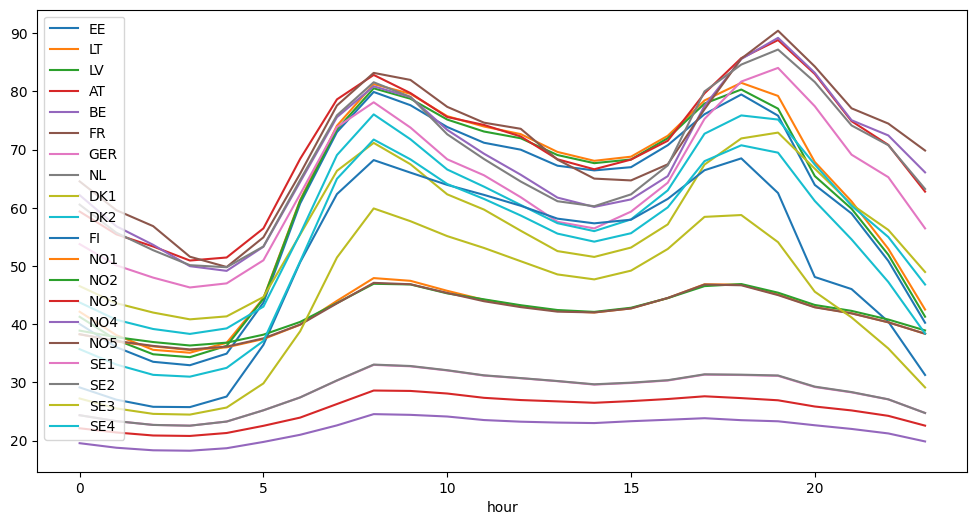

In [109]:
hourly_avg.plot(figsize=(12,6))

In [110]:
import os
import matplotlib.pyplot as plt

groups = {
    "Baltic": ["EE", "LT", "LV"],
    "CWE": ["AT", "BE", "FR", "GER", "NL"],
    "Nordic": ["DK1", "DK2", "FI", "NO1", "NO2", "NO3", "NO4", "NO5", "SE1", "SE2", "SE3", "SE4"],
    "Norway" : ["NO1", "NO2", "NO3", "NO4", "NO5"],
    "Sweden" : ["SE1", "SE2", "SE3", "SE4"],
    "Denmark" : ["DK1", "DK2"]
}

base_path = r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\ExcelFilesNoProcessed\Prices\hourly_prices"
os.makedirs(base_path, exist_ok=True)

hourly_avg = prices.groupby("hour")[price_cols].mean()

for group_name, zones in groups.items():
    plt.figure(figsize=(12, 6))
    
    for zone in zones:
        plt.plot(hourly_avg.index, hourly_avg[zone], label=zone)
    
    plt.title(f'Hourly Average Electricity Prices - {group_name} Markets')
    plt.xlabel('Hour of the day')
    plt.ylabel('Average price (EUR/MWh)')
    plt.xticks(range(24))
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)  
    plt.tight_layout()
    
    plt.savefig(os.path.join(base_path, f"{group_name}_hourly_prices.png"), dpi=300)
    plt.close()

The hourly plots reveal that electricity prices follow a clear intraday structure across all market groups, although the degree of similarity between zones differs considerably. In general, prices tend to be lower during the early morning hours, increase sharply after the beginning of daily activity, and reach their highest values either in the morning or in the evening depending on the market group.

In the Baltic group, the three market areas display very similar hourly profiles, which suggests a relatively homogeneous intraday behaviour. Differences between zones are mainly observed in the price level rather than in the overall shape of the daily curve.

In the CWE group, the market areas also follow a common pattern, although with higher average price levels and a more pronounced evening peak. This indicates a stronger concentration of high prices during the late hours of the day.

By contrast, the Nordic group shows the greatest internal heterogeneity. Although all zones share a broadly similar daily structure, relevant differences can be observed both in average price levels and in the magnitude of hourly fluctuations. This confirms that the Nordic market cannot be treated as fully uniform, especially when comparing Norwegian and Swedish bidding zones with the rest of the group.

<u>4.3.2 Daily evolution of electricity prices</u>

In [111]:
daily_avg = prices.groupby("Delivery day")[price_cols].mean()
print(daily_avg.head())

                     EE         LT         LV         AT         BE  \
Delivery day                                                          
2020-01-01    27.736667  27.736667  27.736667  35.033333  35.448750   
2020-01-02    26.765000  26.765000  26.765000  40.136250  38.995000   
2020-01-03    24.011667  24.011667  24.011667  38.112500  37.766667   
2020-01-04    23.962500  23.962500  23.962500  33.272083  35.648333   
2020-01-05    33.056667  33.056667  33.056667  35.696667  36.259167   

                     FR        GER         NL        DK1        DK2  \
Delivery day                                                          
2020-01-01    35.206250  34.964167  34.578333  30.988750  30.988750   
2020-01-02    39.460833  38.869167  38.780000  30.578750  38.348333   
2020-01-03    36.835000  26.111250  37.245417  23.237917  25.877917   
2020-01-04    34.336667  20.322917  33.757917  19.671250  19.855000   
2020-01-05    36.045417  35.552500  35.177500  30.745417  32.676250   

    

In [112]:
groups = {
    "Baltic": ["EE", "LT", "LV"],
    "CWE": ["AT", "BE", "FR", "GER", "NL"],
    "Nordic": ["DK1", "DK2", "FI", "NO1", "NO2", "NO3", "NO4", "NO5", "SE1", "SE2", "SE3", "SE4"],
    "Norway" : ["NO1", "NO2", "NO3", "NO4", "NO5"],
    "Sweden" : ["SE1", "SE2", "SE3", "SE4"],
    "Denmark" : ["DK1", "DK2"]
}

base_path = r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\ExcelFilesNoProcessed\Prices\daily_prices"
os.makedirs(base_path, exist_ok=True)

daily_avg = prices.groupby("Delivery day")[price_cols].mean()

for group_name, zones in groups.items():
    plt.figure(figsize=(12, 6))
    
    for zone in zones:
        plt.plot(daily_avg.index, daily_avg[zone], label=zone, linewidth=1)
    
    plt.title(f'Daily Average Electricity Prices - {group_name} Markets')
    plt.xlabel('Day')
    plt.ylabel('Average price (EUR/MWh)')
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    
    plt.savefig(os.path.join(base_path, f"{group_name}_daily_prices.png"), dpi=300)
    plt.close()

Conclusions...

<u>4.3.3 Monthly behaviour and seasonal patterns</u>

In [113]:
prices["month"] = prices["Delivery day"].dt.to_period("M")

In [114]:
monthly_avg = prices.groupby("month")[price_cols].mean()
print(monthly_avg.head())

                EE         LT         LV         AT         BE         FR  \
month                                                                       
2020-01  30.821344  30.821344  30.821344  40.702406  37.884624  38.006384   
2020-02  28.105733  27.769986  28.054813  29.109023  28.354770  26.246006   
2020-03  24.022113  23.997510  24.022113  24.603594  24.017995  23.832073   
2020-04  23.694333  23.310167  23.516944  18.307069  14.723833  13.450042   
2020-05  25.021142  24.518320  24.527433  17.523280  15.394462  14.862177   

               GER         NL        DK1        DK2         FI        NO1  \
month                                                                       
2020-01  35.034906  37.102621  24.994543  27.385242  27.163212  24.628562   
2020-02  21.919009  29.557845  17.585072  18.816997  24.434267  12.456868   
2020-03  22.485828  24.740000  18.264455  20.010511  20.377995   8.048977   
2020-04  17.093125  19.009722  14.533778  17.354861  19.820542   4.693097  

In [115]:
groups = {
    "Baltic": ["EE", "LT", "LV"],
    "CWE": ["AT", "BE", "FR", "GER", "NL"],
    "Nordic": ["DK1", "DK2", "FI", "NO1", "NO2", "NO3", "NO4", "NO5", "SE1", "SE2", "SE3", "SE4"],
    "Norway" : ["NO1", "NO2", "NO3", "NO4", "NO5"],
    "Sweden" : ["SE1", "SE2", "SE3", "SE4"],
    "Denmark" : ["DK1", "DK2"]
}

base_path = r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\ExcelFilesNoProcessed\Prices\monthly_prices"
os.makedirs(base_path, exist_ok=True)

prices["month"] = prices["Delivery day"].dt.to_period("M")
monthly_avg = prices.groupby("month")[price_cols].mean()
monthly_avg.index = monthly_avg.index.astype(str)

for group_name, zones in groups.items():
    plt.figure(figsize=(12, 6))
    
    for zone in zones:
        plt.plot(monthly_avg.index, monthly_avg[zone], marker='o', label=zone)
    
    plt.title(f'Monthly Average Electricity Prices - {group_name} Markets')
    plt.xlabel('Month')
    plt.ylabel('Average price (EUR/MWh)')
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.savefig(os.path.join(base_path, f"{group_name}_monthly_prices.png"), dpi=300)
    plt.close()

Conclusions

**4.4 Detection and treatment of missing values**

In [116]:
print(prices.isnull().sum().sum())

0


As part of the exploratory data analysis, the dataset was also checked for missing values. This verification confirmed that the processed prices dataset contains no missing observations across any of the analysed variables. Consequently, no imputation or additional handling of missing data was necessary.

**4.5 Identification of outliers**

<u>Bidding zone outliers</u>

In [117]:
outlier_summary = []

for zone in price_cols:
    q1 = prices[zone].quantile(0.25)
    q3 = prices[zone].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = prices[(prices[zone] < lower_bound) | (prices[zone] > upper_bound)]
    
    outlier_summary.append({
        "Zone": zone,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Lower bound": round(lower_bound, 2),
        "Upper bound": round(upper_bound, 2),
        "Number of outliers": len(outliers),
        "Percentage of outliers": round(len(outliers) / len(prices) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
print(outlier_summary_df.sort_values("Number of outliers", ascending=False))

   Zone     Q1     Q3    IQR  Lower bound  Upper bound  Number of outliers  \
5    FR  30.10  79.16  49.06       -43.49       152.75                2023   
4    BE  29.31  78.43  49.12       -44.37       152.11                1948   
3    AT  31.92  79.76  47.84       -39.84       151.53                1940   
7    NL  30.10  79.19  49.10       -43.55       152.84                1810   
6   GER  28.88  76.32  47.44       -42.27       147.47                1595   
9   DK2  22.43  73.69  51.26       -54.47       150.58                1144   
0    EE  26.93  75.16  48.23       -45.42       147.51                1087   
1    LT  27.98  77.10  49.12       -45.70       150.79                1087   
2    LV  27.34  76.90  49.57       -47.01       151.25                1060   
19  SE4  19.01  67.32  48.31       -53.46       139.79                1056   
8   DK1  21.50  74.44  52.94       -57.91       153.85                1038   
18  SE3  14.37  54.80  40.43       -46.28       115.45          

<u> Maximum and minimum price outliers</u>

In [118]:
extreme_values = pd.DataFrame({
    "Min price": prices[price_cols].min(),
    "Max price": prices[price_cols].max()
}).sort_values("Max price", ascending=False)

print(extreme_values)

     Min price  Max price
EE       -1.73    1000.07
LT       -1.73    1000.07
FI       -1.73    1000.07
LV       -1.73    1000.07
SE4      -1.97     626.06
DK2     -42.66     626.06
SE3      -1.97     626.06
BE     -115.31     620.00
AT      -77.68     620.00
DK1     -58.80     620.00
NL      -79.19     620.00
GER     -83.94     620.00
FR      -75.82     620.00
NO2      -1.97     600.16
NO5      -0.09     600.16
NO1      -1.97     600.16
NO3      -0.01     360.00
NO4      -0.01     360.00
SE1      -1.97     360.00
SE2      -1.97     360.00


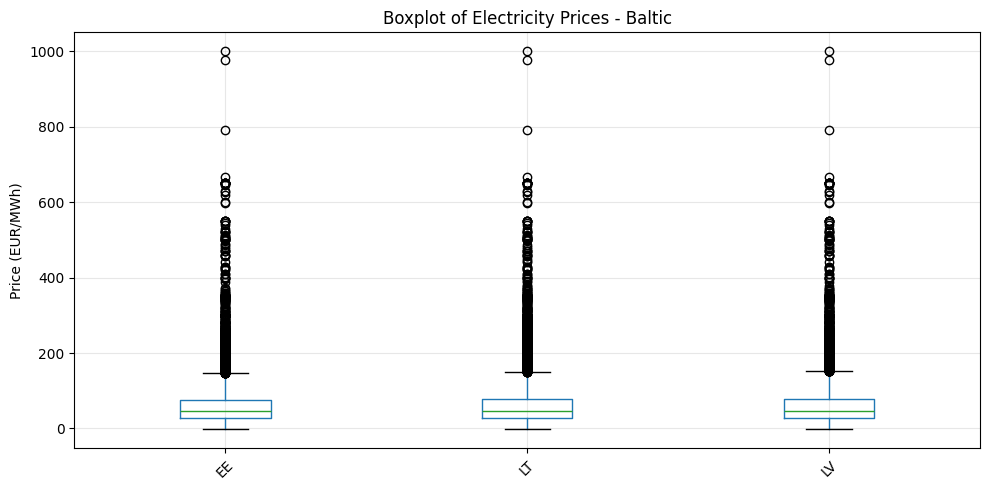

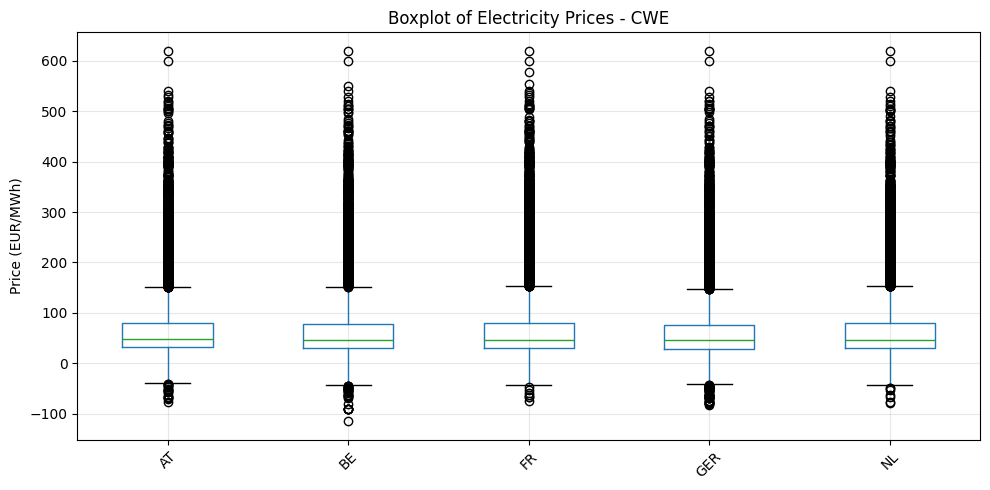

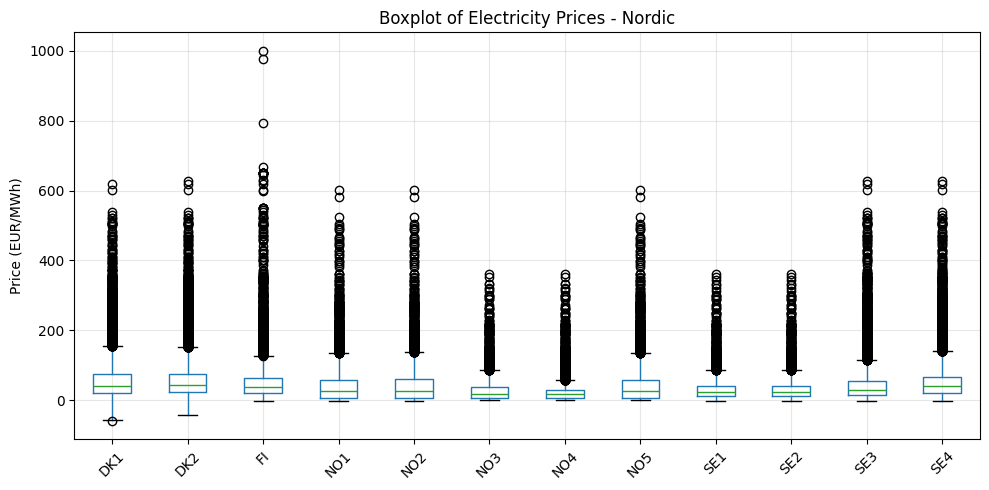

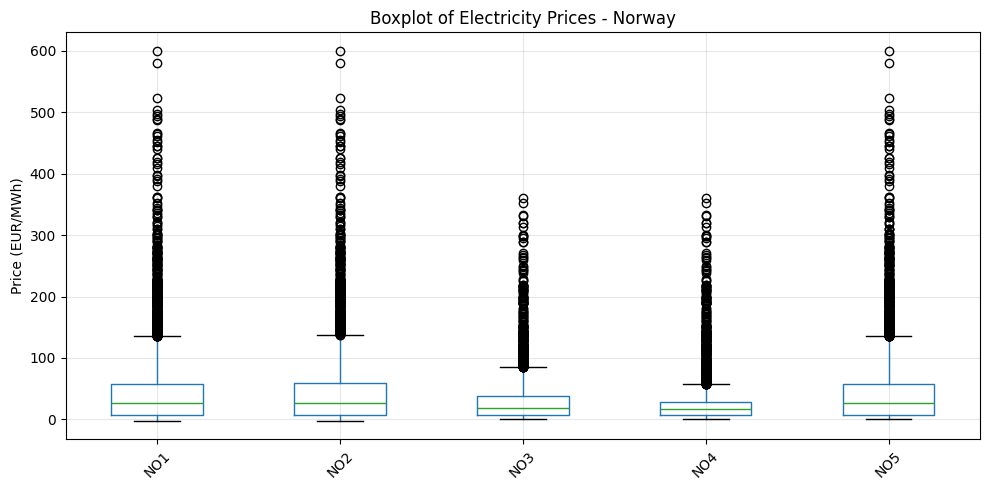

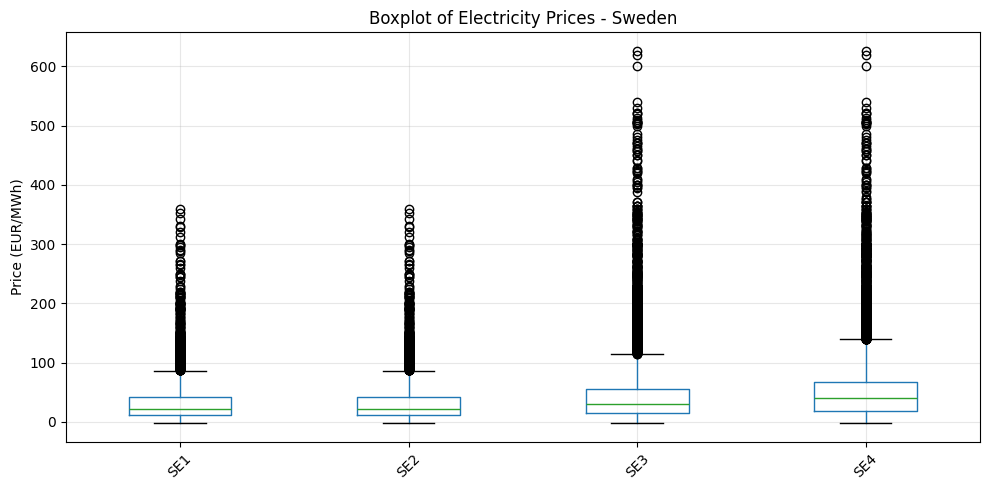

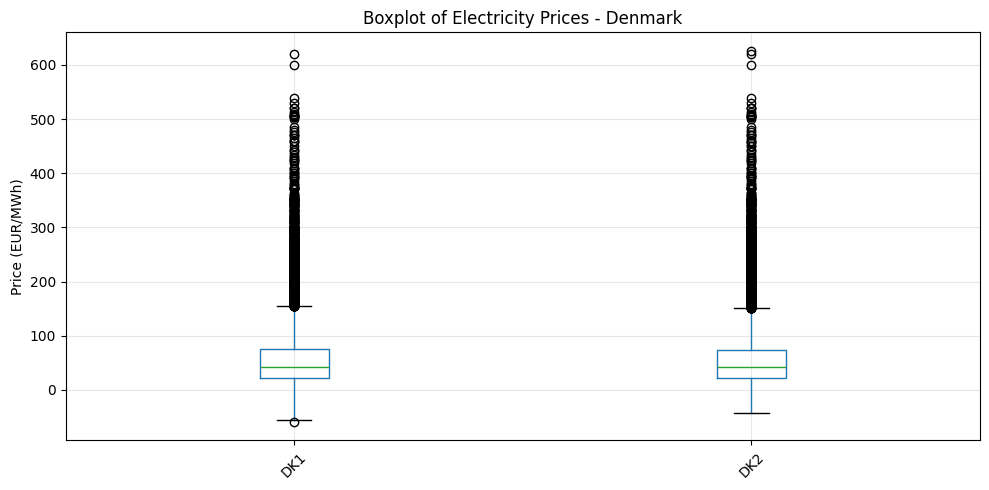

In [119]:
groups = {
    "Baltic": ["EE", "LT", "LV"],
    "CWE": ["AT", "BE", "FR", "GER", "NL"],
    "Nordic": ["DK1", "DK2", "FI", "NO1", "NO2", "NO3", "NO4", "NO5", "SE1", "SE2", "SE3", "SE4"],
    "Norway": ["NO1", "NO2", "NO3", "NO4", "NO5"],
    "Sweden": ["SE1", "SE2", "SE3", "SE4"],
    "Denmark": ["DK1", "DK2"]
}

for group_name, zones in groups.items():
    plt.figure(figsize=(10, 5))
    prices[zones].boxplot(showfliers=True)
    
    plt.title(f'Boxplot of Electricity Prices - {group_name}')
    plt.ylabel('Price (EUR/MWh)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.show()

The outlier analysis highlights the presence of frequent and significant extreme price events across all market areas. These extreme values, particularly positive price spikes, are not isolated anomalies but rather intrinsic characteristics of electricity markets.

While Baltic and CWE markets show relatively homogeneous behaviour across their respective zones, the Nordic market presents a much higher degree of internal heterogeneity. In particular, clear structural differences are observed within Norway and Sweden, where northern and southern zones exhibit markedly different price distributions.

Additionally, the presence of negative prices in several markets confirms the occurrence of specific supply-demand imbalances. Overall, these findings reinforce the importance of considering both spatial and temporal variability when analysing electricity price dynamics.

**4.6 Correlation analysis**

<u> Correlation matrix</u>

In [120]:
correlation_matrix = prices[price_cols].corr()
print(correlation_matrix)

           EE        LT        LV        AT        BE        FR       GER  \
EE   1.000000  0.981523  0.988417  0.814115  0.780664  0.784755  0.821464   
LT   0.981523  1.000000  0.992963  0.837472  0.804971  0.808340  0.848228   
LV   0.988417  0.992963  1.000000  0.829012  0.796723  0.800945  0.837258   
AT   0.814115  0.837472  0.829012  1.000000  0.968943  0.977230  0.959542   
BE   0.780664  0.804971  0.796723  0.968943  1.000000  0.977284  0.951007   
FR   0.784755  0.808340  0.800945  0.977230  0.977284  1.000000  0.930900   
GER  0.821464  0.848228  0.837258  0.959542  0.951007  0.930900  1.000000   
NL   0.788684  0.812600  0.803605  0.963519  0.979977  0.962538  0.950162   
DK1  0.828273  0.856621  0.845284  0.899209  0.891223  0.869070  0.943754   
DK2  0.869910  0.893762  0.883751  0.864513  0.846129  0.827409  0.911219   
FI   0.935620  0.919335  0.927207  0.734552  0.699276  0.709963  0.746552   
NO1  0.790656  0.801691  0.799636  0.875285  0.859921  0.865787  0.857350   

<u> Heatmap of correlations</u>

In [121]:
groups = {
    "Baltic": ["EE", "LT", "LV"],
    "CWE": ["AT", "BE", "FR", "GER", "NL"],
    "Nordic": ["DK1", "DK2", "FI", "NO1", "NO2", "NO3", "NO4", "NO5", "SE1", "SE2", "SE3", "SE4"],
    "Norway": ["NO1", "NO2", "NO3", "NO4", "NO5"],
    "Sweden": ["SE1", "SE2", "SE3", "SE4"],
    "Denmark": ["DK1", "DK2"]
}

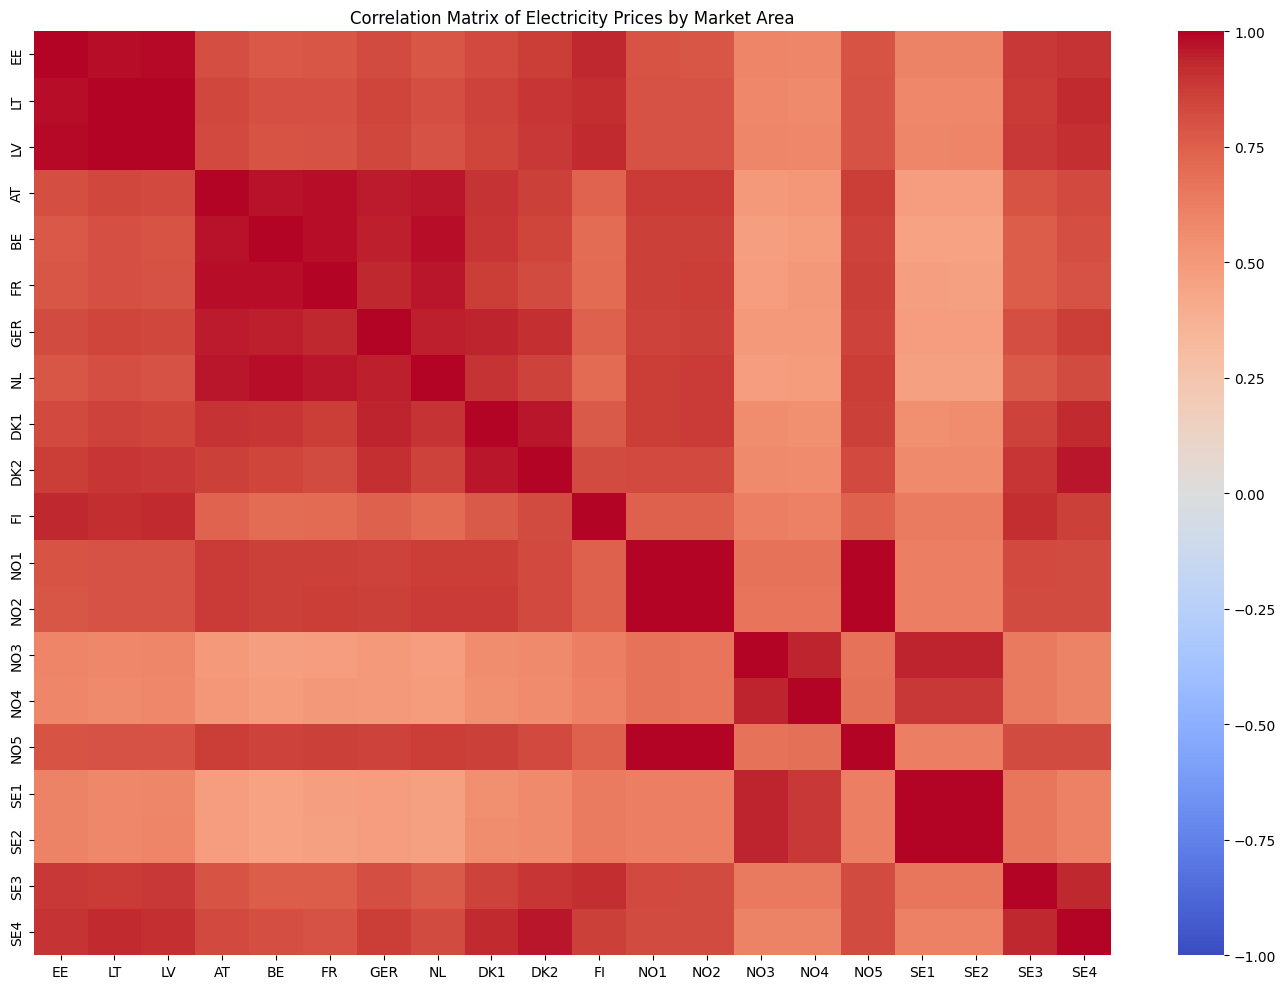

In [123]:
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Electricity Prices by Market Area")
plt.tight_layout()
plt.show()

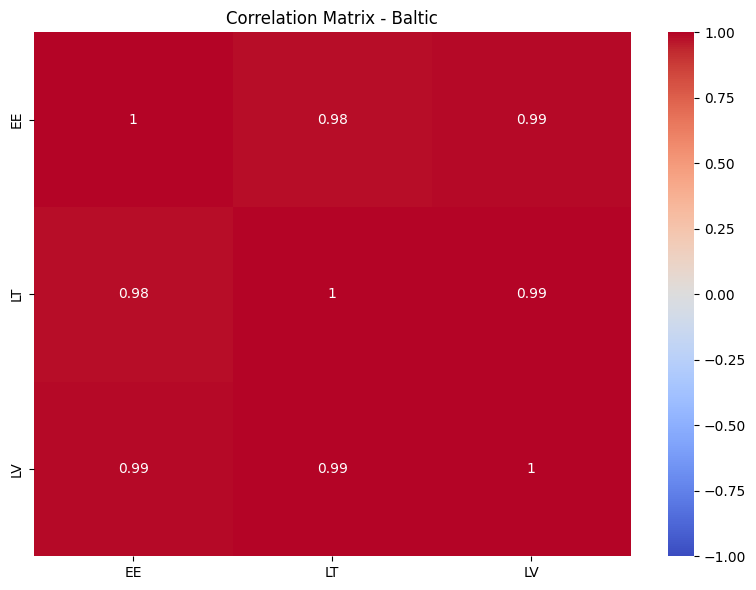

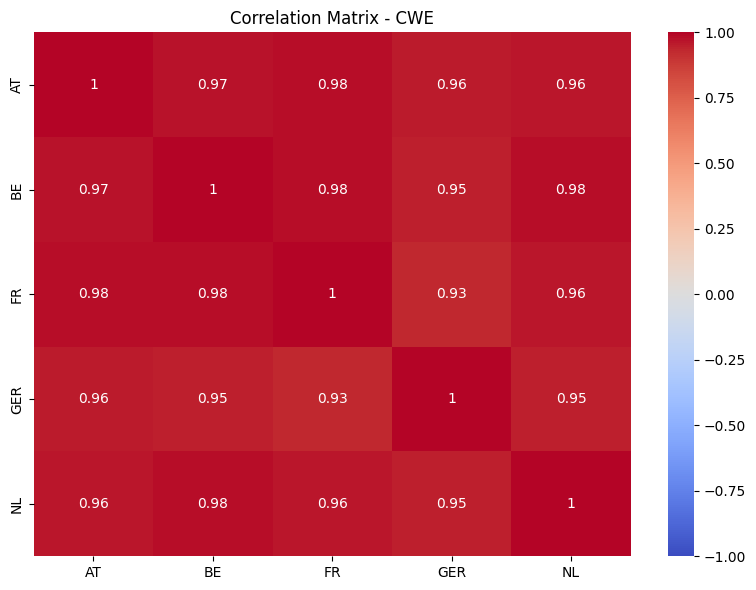

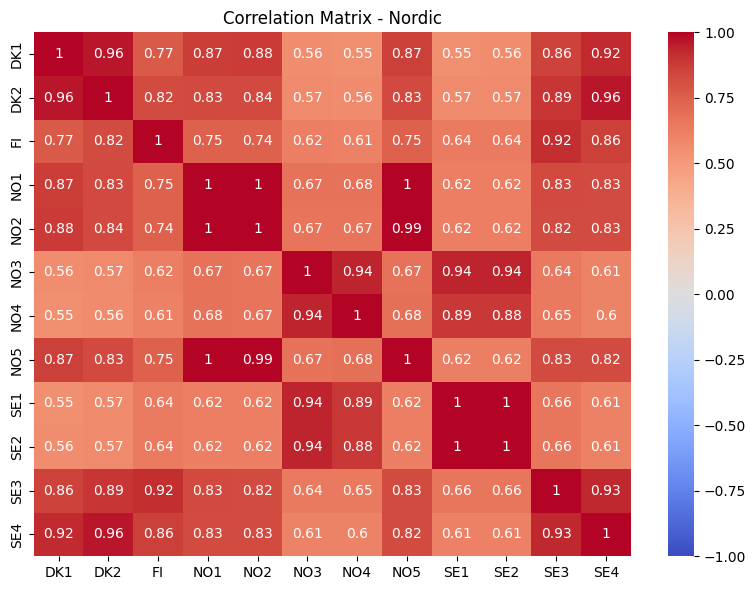

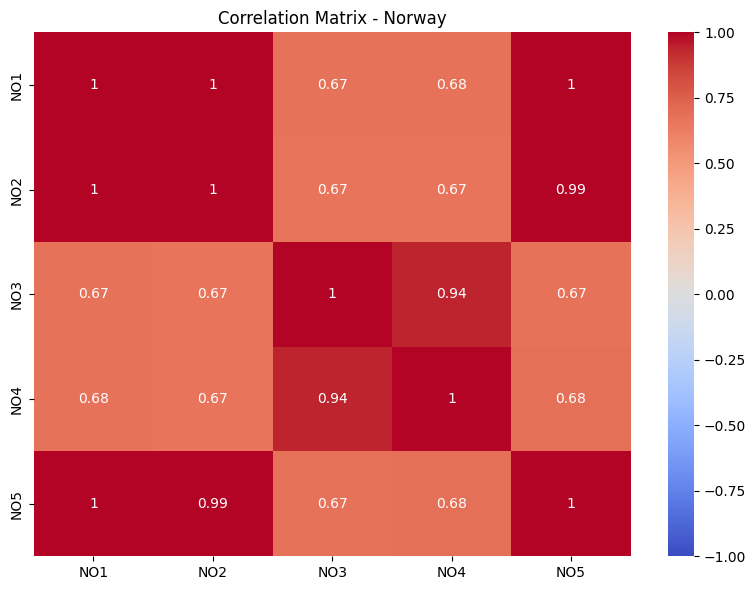

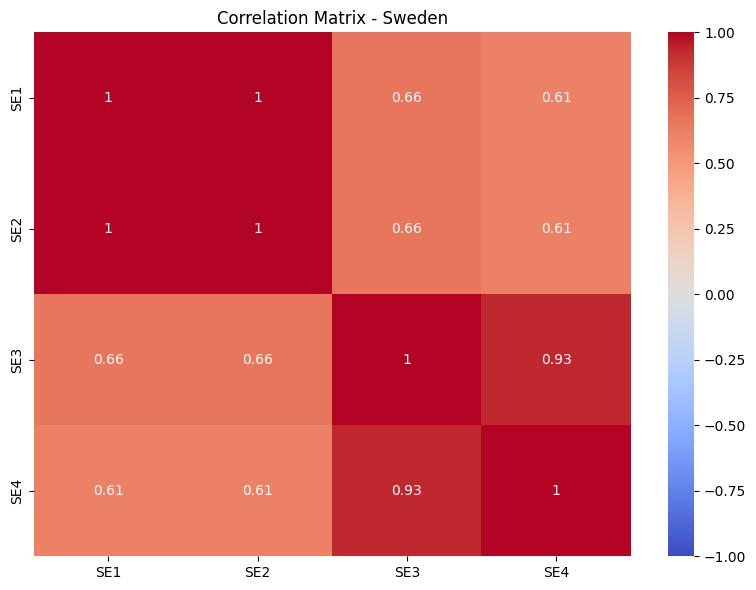

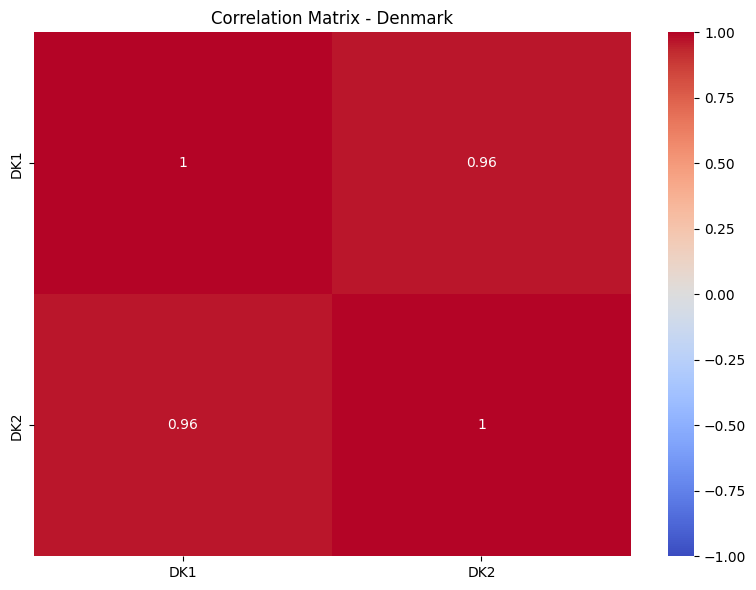

In [122]:
import seaborn as sns

for group_name, zones in groups.items():
    corr = prices[zones].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title(f"Correlation Matrix - {group_name}")
    plt.tight_layout()
    plt.show()

The correlation analysis reveals a high degree of synchronization within most market groups, particularly in the Baltic and CWE regions, where electricity prices exhibit strong positive correlations across all areas. This indicates a high level of market integration and similar responses to underlying market conditions.

In contrast, the Nordic market displays a more complex structure, with clear subgroups of highly correlated zones. In particular, southern zones such as NO1, NO2, NO5, SE3, SE4, and the Danish bidding areas show strong correlations both internally and with Central European markets. On the other hand, northern zones such as NO3, NO4, SE1, and SE2 form a distinct cluster with lower price levels and weaker correlations with southern regions.

This pattern is especially evident in Norway, where two well-defined submarkets can be identified: a southern cluster with very high internal correlation, and a northern cluster that behaves more independently.

Overall, these results confirm that while some electricity markets behave in a highly integrated manner, others exhibit significant spatial heterogeneity, which must be taken into account in further analysis and modelling.